# Beauty Trend Intelligence System
## Neural Consumer Archetypes × Google Trends Signal
### Advanced Machine Learning — Final Project

**Market:** United States Beauty Industry (Skincare + Makeup)  
**Data:** April 2024 – April 2026  
**Author:** Carolina Galindo Mendoza

---


## Project Overview

This project builds a **Beauty Trend Intelligence System** that answers two questions for US beauty brands:

1. Which emerging beauty trends should we invest in *right now*?
2. Which consumer segment will adopt each trend faster — and through which channel?

The system fuses three real data sources through a four-layer pipeline of neural and statistical models, producing actionable trend rankings and segment-specific momentum forecasts.

---


## System Architecture

```
┌──────────────────────────────────────────────────────────────┐
│                        DATA LAYER                            │
│   Consumer Behavioral Data (11,789 × 25)                     │
│   + Google Trends Time Series (15 trends, 24 months, US)     │
│   + Google Trends Query Signals (rising + top queries)       │
└────────────────────┬─────────────────────────────────────────┘
                     │
          ┌──────────▼──────────┐
          │      LAYER 1        │  Unsupervised Neural Network
          │    Autoencoder      │  Forward + Backpropagation
          │   25 → 8 → 25       │  Learns behavioral embeddings
          └──────────┬──────────┘
                     │ 8-dim latent embeddings
          ┌──────────▼──────────┐
          │      LAYER 2        │  Unsupervised Clustering
          │      K-Means        │  Applied to neural embeddings
          │    k=2 archetypes   │  Not raw features
          └──────────┬──────────┘
                     │ segment behavioral vectors (8-dim)
                     │                    │
          ┌──────────▼──────────┐         │
          │      LAYER 3        │         │ ← passed into FFNN
          │  Trend Engineering  │         │
          │  15 trends × 14     │         │
          │  signal features    │         │
          └──────────┬──────────┘         │
                     │ trend window        │
                     │ features (10-dim)   │
          ┌──────────▼─────────────────────▼──────┐
          │              LAYER 4                   │  Supervised Neural Network
          │     FFNN Segment-Aware Predictor       │  Forward + Backpropagation
          │   Input: trend (10) + segment (8) = 18 │  Predicts segment-specific
          │   Output: adoption momentum score      │  trend momentum
          └──────────────────┬─────────────────────┘
                             │
          ┌──────────────────▼─────────────────────┐
          │              OUTPUT                     │
          │  Trend rankings + segment momentum      │
          │  forecasts per archetype                │
          └─────────────────────────────────────────┘
```


## ML Techniques Inventory

| Technique | Component | Type |
|---|---|---|
| Autoencoder | Consumer behavioral embedding | Unsupervised Neural Network |
| Forward Propagation | Autoencoder + FFNN training | Neural Network mechanism |
| Backpropagation | Autoencoder + FFNN weight updates | Gradient-based optimization |
| K-Means Clustering | Archetype discovery | Unsupervised Learning |
| FFNN Regression | Segment-aware momentum prediction | Supervised Learning |
| UMAP | Latent space visualization | Dimensionality Reduction |
| Representation Learning | 25→8 compression | Feature Learning |
| Time Series Feature Engineering | Sliding window extraction | Signal Processing |
| Multi-source Data Fusion | Behavioral + search + query signals | Data Integration |

## 1. Problem Framing

### What are we trying to do?
A US beauty brand faces a recurring resource allocation problem: dozens of trends emerge every quarter across skincare and makeup, but marketing budgets are finite. Investing in the wrong trend — or targeting the wrong consumer segment — is costly and hard to reverse.

This system provides a **data-driven prioritization tool** that:
- Segments consumers into behavioral archetypes using neural embeddings learned from real behavioral data
- Scores and ranks 15 emerging beauty trends by US market momentum signals
- Predicts **segment-specific trend adoption momentum** — how fast will *this segment* respond to *this trend*?
- Maps channel strategy (digital vs in-store) to each consumer archetype based on their behavioral profile

### Why does it matter?
The US beauty market exceeded $100B in 2024. Trend misalignment — launching a declining trend, or targeting the wrong consumer segment through the wrong channel — directly impacts campaign ROI and inventory decisions. A system that detects momentum early and matches trends to segments gives marketing teams a measurable, data-driven starting point.

### The core question this model answers
> *"For each emerging beauty trend in the US market, which consumer segment will adopt it faster — and how confident are we in that signal?"*

### An important modeling assumption
This system does **not** have access to observed adoption data — we cannot directly measure how many Digital Natives purchased a peptide serum in a given month. Instead, the FFNN's training targets are **behaviorally-weighted momentum scores**: trend momentum signals scaled by how aligned each segment's behavioral profile is with that trend type. This is a modeling assumption that could be wrong. It is documented fully in the Evaluation section.

## 2. Data

### Sources

| Source | Description | Shape |
|---|---|---|
| Consumer Behavioral Dataset (Kaggle) | 25 behavioral + demographic features per consumer | (11,789 × 25) |
| Google Trends Time Series (US) | Monthly search interest, 15 beauty trends, 24 months | (25 × 16) |
| Google Trends — Top Queries (US) | Highest-volume related searches per trend | (598 × 4) |
| Google Trends — Rising Queries (US) | Breakout and high-growth related searches per trend | (598 × 4) |

### Consumer Dataset Features
25 features covering: purchase channel preference, tech engagement scores, psychographic measures (impulse buying, brand loyalty, environmental awareness, touch-feel need), spend patterns across online and in-store channels, and demographic variables. No missing values across all 11,789 records.

### Trend Keywords Tracked (15 Beauty Trends)
Selected to span different lifecycle stages across skincare and makeup:

**Skincare:** waterless beauty, skin barrier repair, scalp microbiome, slugging skincare, peptide serum, retinol alternative, retinol serum, glass skin, SPF makeup, tinted moisturizer  
**Makeup:** lip liner, liquid blush, solid perfume, clean girl makeup, skincare makeup

### Key Data Decisions

**StandardScaler before autoencoder:** Features ranged from 1–10 psychographic scores to raw spend values in the hundreds of thousands. Without scaling, high-magnitude features dominate the loss function and the autoencoder learns nothing useful about psychographic variation.

**US Market Scope (`geo='US'`):** Global trends aggregate wildly different consumer markets. US-scoped signals reflect a coherent market relevant to a US beauty brand.

**Minimum Volume Filter:** Keywords with mean search interest below 5/100 in the US were dropped. This revealed that Digital Native keywords like `viral skincare TikTok` returned near-zero US search volume — not a data error, but a genuine behavioral finding (see Narrative).

**Trend Indicator Column:** Rising and top query files enriched with a trend indicator column to enable accurate query grouping by parent keyword.

**Sliding Window Augmentation:** Applied across the 24-month time series to generate multiple training samples per trend. Each window of 8 months predicts momentum in the following 4 months. Samples are generated twice — once per archetype — integrating segment behavioral vectors directly into FFNN training.

## Approach


### Phase 1 — Exploratory Data Analysis

Loading and diagnosing the consumer behavioral dataset before any modeling. Key checks: shape, data types, missing values, feature distributions, correlation structure, and shopping preference breakdown.

Using Colab cache for faster access to the 'consumer-shopping-trends-analysis' dataset.
Dataset path: /kaggle/input/consumer-shopping-trends-analysis
Files: ['Consumer_Shopping_Trends_2026 (6).csv']

✓ Dataset loaded: (11789, 25)

DATASET DIAGNOSTIC
Shape         : (11789, 25)
Missing values: 0
Duplicates    : 0

Data types:
age                              int64
monthly_income                   int64
daily_internet_hours           float64
smartphone_usage_years           int64
social_media_hours             float64
online_payment_trust_score       int64
tech_savvy_score                 int64
monthly_online_orders            int64
monthly_store_visits             int64
avg_online_spend                 int64
avg_store_spend                  int64
discount_sensitivity             int64
return_frequency                 int64
avg_delivery_days                int64
delivery_fee_sensitivity         int64
free_return_importance           int64
product_availability_online      int64
impulse_bu

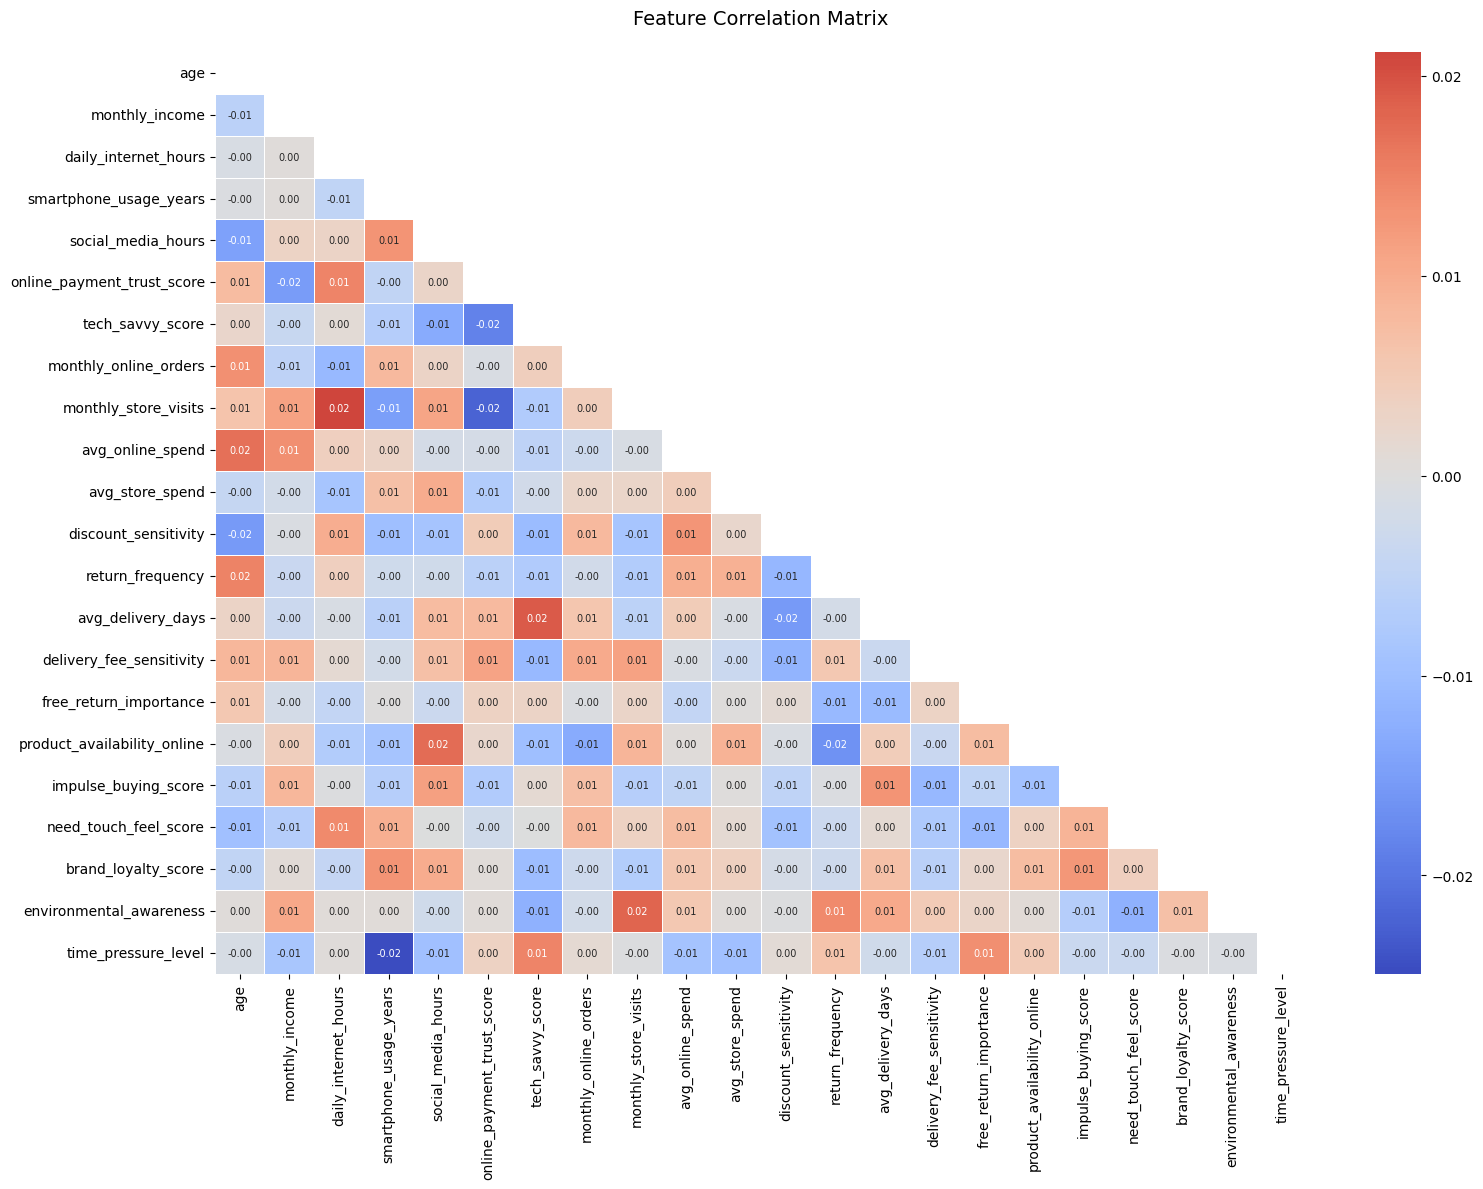

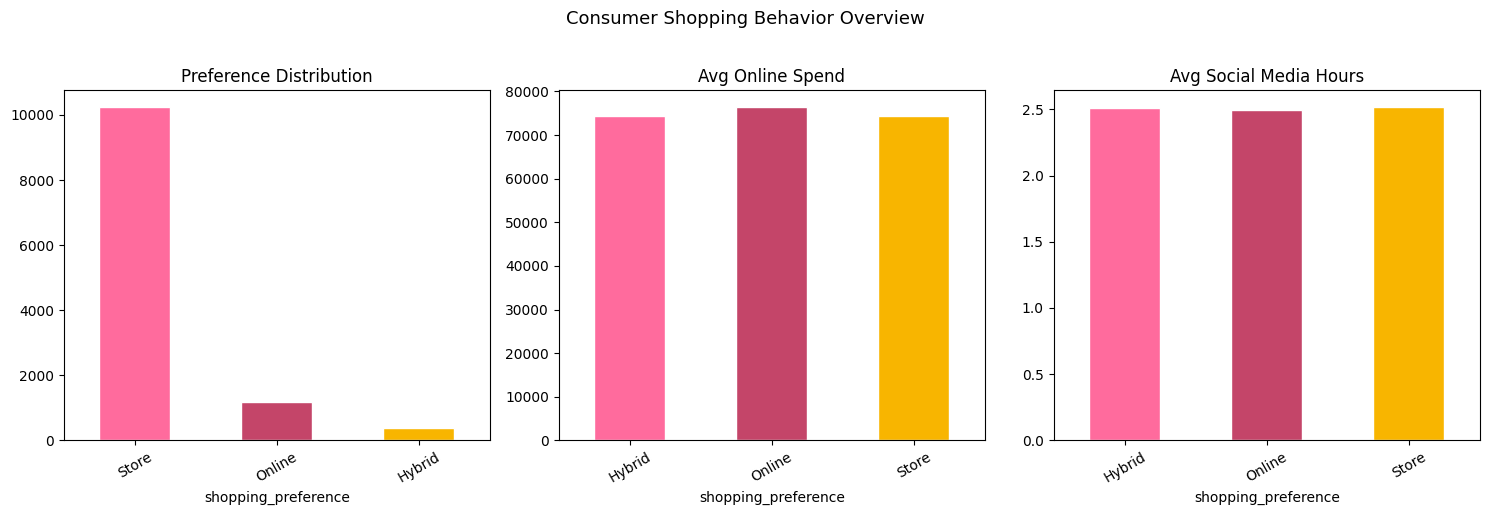

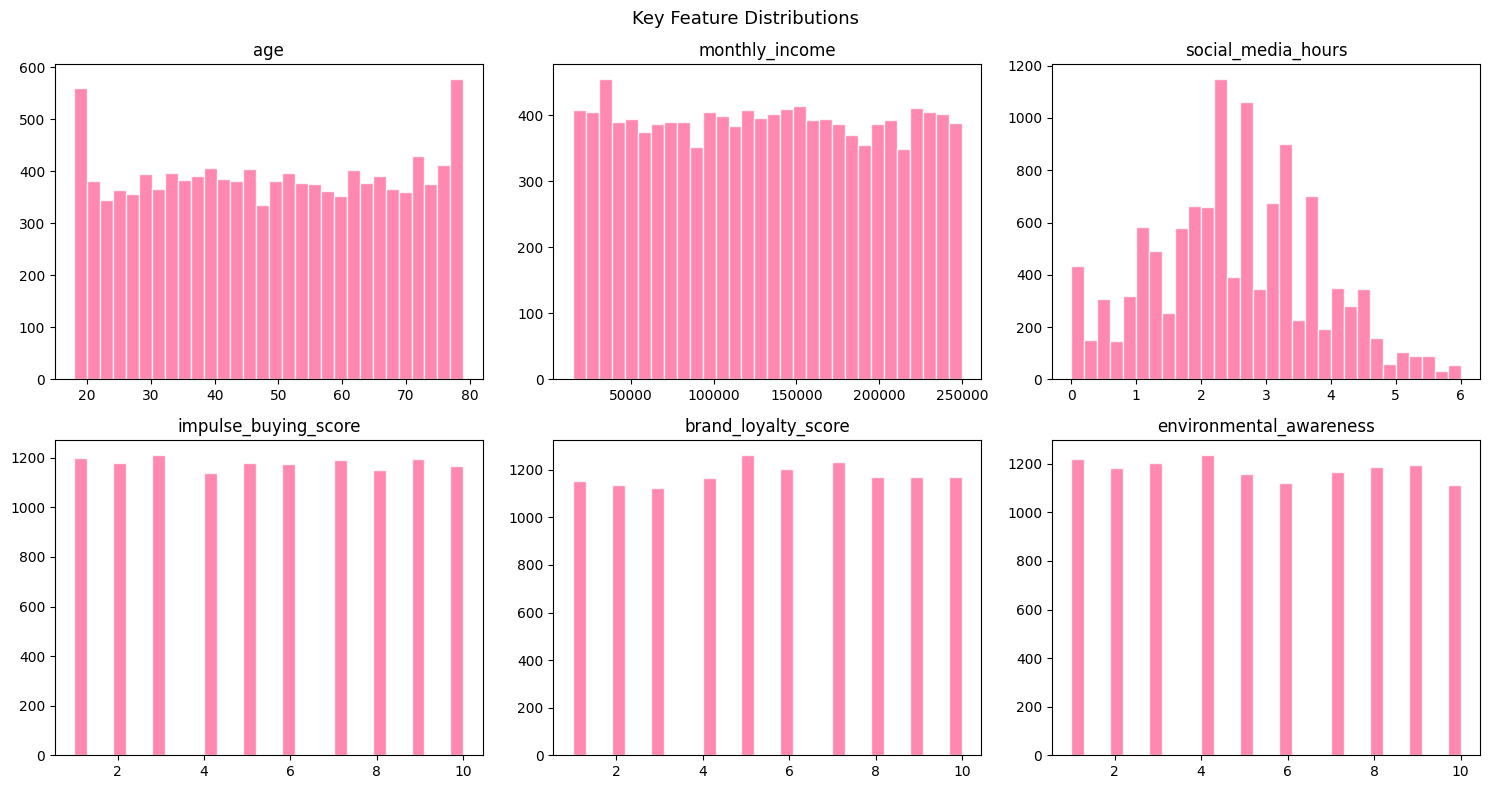


EDA COMPLETE
✓ 22 numeric features | 11789 consumers | 0 missing values


In [ ]:
# ============================================================
# PHASE 1: ENVIRONMENT SETUP & EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ────────────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("minahilfatima12328/consumer-shopping-trends-analysis")
print("Dataset path:", path)

import os
print(f"Files: {os.listdir(path)}")

file_name = 'Consumer_Shopping_Trends_2026 (6).csv'
file_path = os.path.join(path, file_name)
df        = pd.read_csv(file_path)
print(f"\n✓ Dataset loaded: {df.shape}")

# ── DIAGNOSTIC ───────────────────────────────────────────────
print("\n" + "="*55)
print("DATASET DIAGNOSTIC")
print("="*55)
print(f"Shape         : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes}")

# ── DESCRIPTIVE STATISTICS ───────────────────────────────────
print("\n" + "="*55)
print("DESCRIPTIVE STATISTICS")
print("="*55)
print(df.describe().round(2))

# ── CATEGORICAL DISTRIBUTIONS ────────────────────────────────
print("\n" + "="*55)
print("CATEGORICAL DISTRIBUTIONS")
print("="*55)
for col in ['gender', 'city_tier', 'shopping_preference']:
    print(f"\n{col}:\n{df[col].value_counts()}")

# ── CORRELATION HEATMAP ──────────────────────────────────────
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr       = numeric_df.corr()
mask       = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 7}, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ── SHOPPING PREFERENCE BREAKDOWN ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, title) in zip(axes, [
    ('shopping_preference', 'Preference Distribution'),
    ('avg_online_spend',    'Avg Online Spend'),
    ('social_media_hours',  'Avg Social Media Hours')
]):
    if col == 'shopping_preference':
        df[col].value_counts().plot(kind='bar', ax=ax,
            color=['#FF6B9D','#C44569','#F8B500'], edgecolor='white')
    else:
        df.groupby('shopping_preference')[col].mean().plot(kind='bar', ax=ax,
            color=['#FF6B9D','#C44569','#F8B500'], edgecolor='white')
    ax.set_title(title); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Consumer Shopping Behavior Overview', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── KEY FEATURE DISTRIBUTIONS ────────────────────────────────
key_feats = ['age','monthly_income','social_media_hours',
             'impulse_buying_score','brand_loyalty_score','environmental_awareness']
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
for i, feat in enumerate(key_feats):
    axes[i].hist(df[feat], bins=30, color='#FF6B9D', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat)
plt.suptitle('Key Feature Distributions', fontsize=13)
plt.tight_layout(); plt.show()

print("\n" + "="*55)
print("EDA COMPLETE")
print("="*55)
print(f"✓ {len(numeric_df.columns)} numeric features | {len(df)} consumers | 0 missing values")

### Phase 2 — Feature Engineering + Autoencoder

**Architecture:** 25 → 64 → 32 → **8** → 32 → 64 → 25

The autoencoder learns a compressed 8-dimensional representation of each consumer's behavioral profile. This latent space is the foundation for consumer archetype discovery in Phase 3, and the resulting segment vectors are passed directly into the FFNN in Phase 5.

**Why an autoencoder instead of direct clustering on raw features?**  
Raw features are on incompatible scales and include redundant information. The autoencoder forces the model to learn which combinations of features carry the most structural information about consumer behavior — the latent space is a more meaningful distance metric for clustering than Euclidean distance on raw features.

**Key design decisions:**
- **Latent dim = 8:** Small enough to force dominant structure, large enough to preserve behavioral variation. *This decision could be wrong* — a higher bottleneck might reveal sub-segments within the large Traditional Shopper cluster that our model currently cannot see.
- **Tanh activation on bottleneck:** Bounds the latent space to [-1, 1], preventing embedding collapse and making K-Means distances more interpretable.
- **BatchNorm + Dropout:** Regularization to prevent overfitting. Note that val loss going below train loss is expected — Dropout is active during training but disabled during validation.
- **Forward propagation** computes the reconstruction from input through encoder and decoder. **Backpropagation** computes gradients of MSE reconstruction loss and updates all 8,417 parameters via Adam optimizer.

Gender classes   : ['Female' 'Male' 'Other']
City tier classes: ['Tier 1' 'Tier 2' 'Tier 3']
Pref classes     : ['Hybrid' 'Online' 'Store']

✓ Feature matrix: (11789, 25) | mean≈0, std≈1
✓ Train: 10020 | Val: 1769

✓ Device: cpu
✓ Trainable parameters: 8,417
ConsumerAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=8, bias=True)
    (9): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_

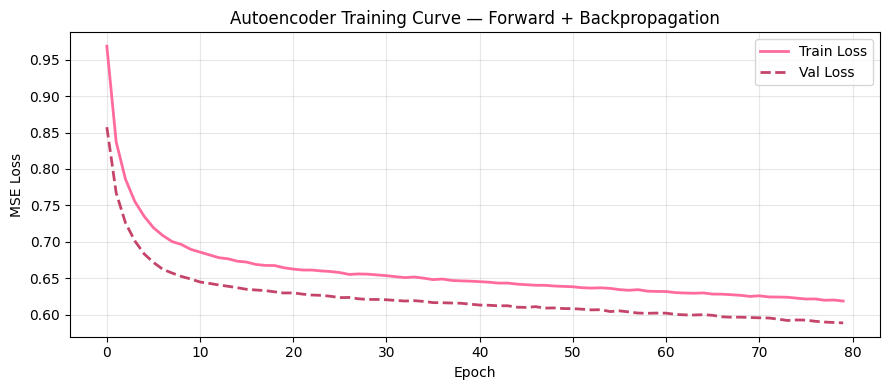


✓ Latent embeddings: (11789, 8)
  Each consumer → point in 8-dimensional learned space
  These embeddings feed directly into Phase 3 clustering


In [ ]:
# ============================================================
# PHASE 2: FEATURE ENGINEERING + AUTOENCODER
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import copy

# ── 1. ENCODE CATEGORICALS ──────────────────────────────────
df_model = df.copy()

le_gender = LabelEncoder()
le_city   = LabelEncoder()
le_pref   = LabelEncoder()

df_model['gender_enc'] = le_gender.fit_transform(df_model['gender'])
df_model['city_enc']   = le_city.fit_transform(df_model['city_tier'])
df_model['pref_enc']   = le_pref.fit_transform(df_model['shopping_preference'])

print("Gender classes   :", le_gender.classes_)
print("City tier classes:", le_city.classes_)
print("Pref classes     :", le_pref.classes_)

# ── 2. SCALE FEATURES ────────────────────────────────────────
# StandardScaler is critical: features range from 1-10 scores
# to raw spend values in the hundreds of thousands.
# Without scaling, high-magnitude features dominate the loss.

feature_cols = [
    'age','monthly_income','daily_internet_hours',
    'smartphone_usage_years','social_media_hours',
    'online_payment_trust_score','tech_savvy_score',
    'monthly_online_orders','monthly_store_visits',
    'avg_online_spend','avg_store_spend',
    'discount_sensitivity','return_frequency',
    'avg_delivery_days','delivery_fee_sensitivity',
    'free_return_importance','product_availability_online',
    'impulse_buying_score','need_touch_feel_score',
    'brand_loyalty_score','environmental_awareness',
    'time_pressure_level','gender_enc','city_enc','pref_enc'
]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_model[feature_cols].values)

print(f"\n✓ Feature matrix: {X_scaled.shape} | mean≈0, std≈1")

# ── 3. TRAIN / VAL SPLIT ────────────────────────────────────
X_train, X_val = train_test_split(X_scaled, test_size=0.15, random_state=42)

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
    batch_size=256, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(X_val)),
    batch_size=256, shuffle=False)

print(f"✓ Train: {len(X_train)} | Val: {len(X_val)}")

# ── 4. AUTOENCODER ARCHITECTURE ─────────────────────────────
INPUT_DIM  = X_scaled.shape[1]   # 25
LATENT_DIM = 8                   # bottleneck

class ConsumerAutoencoder(nn.Module):
    """
    Symmetric autoencoder for consumer behavioral embedding.
    Encoder: 25 → 64 → 32 → 8  (compression)
    Decoder: 8  → 32 → 64 → 25 (reconstruction)
    Trained to minimize MSE reconstruction loss via
    forward propagation + backpropagation.
    """
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32),
            nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, latent_dim), nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 64),         nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ConsumerAutoencoder(INPUT_DIM, LATENT_DIM).to(device)

print(f"\n✓ Device: {device}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(model)

# ── 5. TRAINING — FORWARD + BACKPROPAGATION ──────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

EPOCHS = 80
best_val_loss, best_state = float('inf'), None
train_losses, val_losses  = [], []

print("\n" + "="*55)
print("TRAINING AUTOENCODER")
print("="*55)

for epoch in range(1, EPOCHS + 1):
    # FORWARD PROPAGATION: input → encoder → decoder → reconstruction
    model.train()
    t_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon, _ = model(xb)              # forward pass
        loss     = criterion(recon, xb)
        loss.backward()                   # BACKPROPAGATION
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * xb.size(0)
    t_loss /= len(X_train)

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            recon, _ = model(xb)
            v_loss  += criterion(recon, xb).item() * xb.size(0)
    v_loss /= len(X_val)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state    = copy.deepcopy(model.state_dict())

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {t_loss:.5f} | Val: {v_loss:.5f}"
              + (" ← best" if v_loss == best_val_loss else ""))

model.load_state_dict(best_state)
print(f"\n✓ Best validation loss: {best_val_loss:.5f}")
print(f"✓ Note: val < train loss is expected — Dropout active only during training")

# ── 6. TRAINING CURVE ────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='#FF6B9D', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='#C44569', linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve — Forward + Backpropagation', fontsize=12)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── 7. EXTRACT LATENT EMBEDDINGS ────────────────────────────
model.eval()
with torch.no_grad():
    embeddings = model.encode(
        torch.FloatTensor(X_scaled).to(device)).cpu().numpy()

print(f"\n✓ Latent embeddings: {embeddings.shape}")
print("  Each consumer → point in 8-dimensional learned space")
print("  These embeddings feed directly into Phase 3 clustering")

### Phase 3 — K-Means Clustering on Neural Embeddings

K-Means is applied to the **8-dimensional latent embeddings** from the autoencoder — not the raw features. This is a meaningful distinction: clustering in the learned latent space means we are grouping consumers by patterns the neural network found meaningful, not by arbitrary raw feature proximity.

**Why k=2?** Silhouette scores were tested for k=2 through k=10. The score peaked sharply at k=2 (0.2475), dropping to ~0.12 for k≥3. An initial k=4 run was also explored — UMAP visualization revealed one isolated cluster mapping perfectly to online shoppers, confirming k=2 as the statistically and visually optimal choice.

**The segment behavioral vectors produced here are passed directly into the FFNN in Phase 5.** This is the architectural connection between the consumer segmentation pipeline and the trend prediction model.

FINDING OPTIMAL k
  k= 2 | Silhouette: 0.2689 | DB: 1.5221 | Inertia: 4443.5
  k= 3 | Silhouette: 0.1215 | DB: 2.2630 | Inertia: 4017.4
  k= 4 | Silhouette: 0.1247 | DB: 2.0844 | Inertia: 3708.6
  k= 5 | Silhouette: 0.1194 | DB: 1.9909 | Inertia: 3484.1
  k= 6 | Silhouette: 0.1155 | DB: 1.9204 | Inertia: 3323.3
  k= 7 | Silhouette: 0.1158 | DB: 1.8437 | Inertia: 3185.9
  k= 8 | Silhouette: 0.1166 | DB: 1.7501 | Inertia: 3057.4
  k= 9 | Silhouette: 0.1168 | DB: 1.7151 | Inertia: 2968.6
  k=10 | Silhouette: 0.1101 | DB: 1.7199 | Inertia: 2884.0


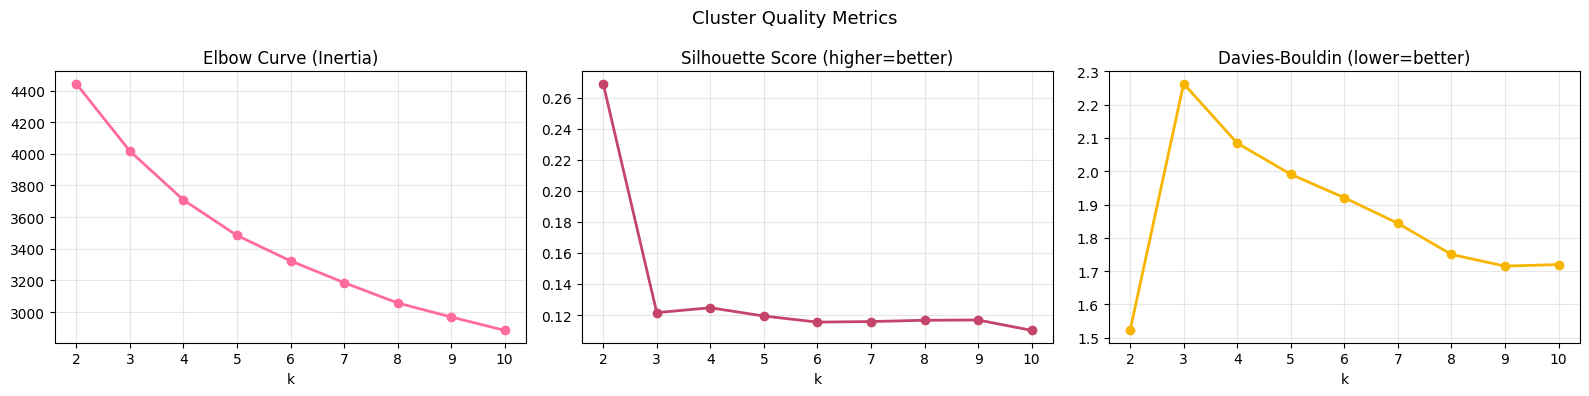


✓ k=2 | Silhouette: 0.2689 | Davies-Bouldin: 1.5221
✓ Cluster sizes: {0: 1571, 1: 10218}

Fitting UMAP projection...


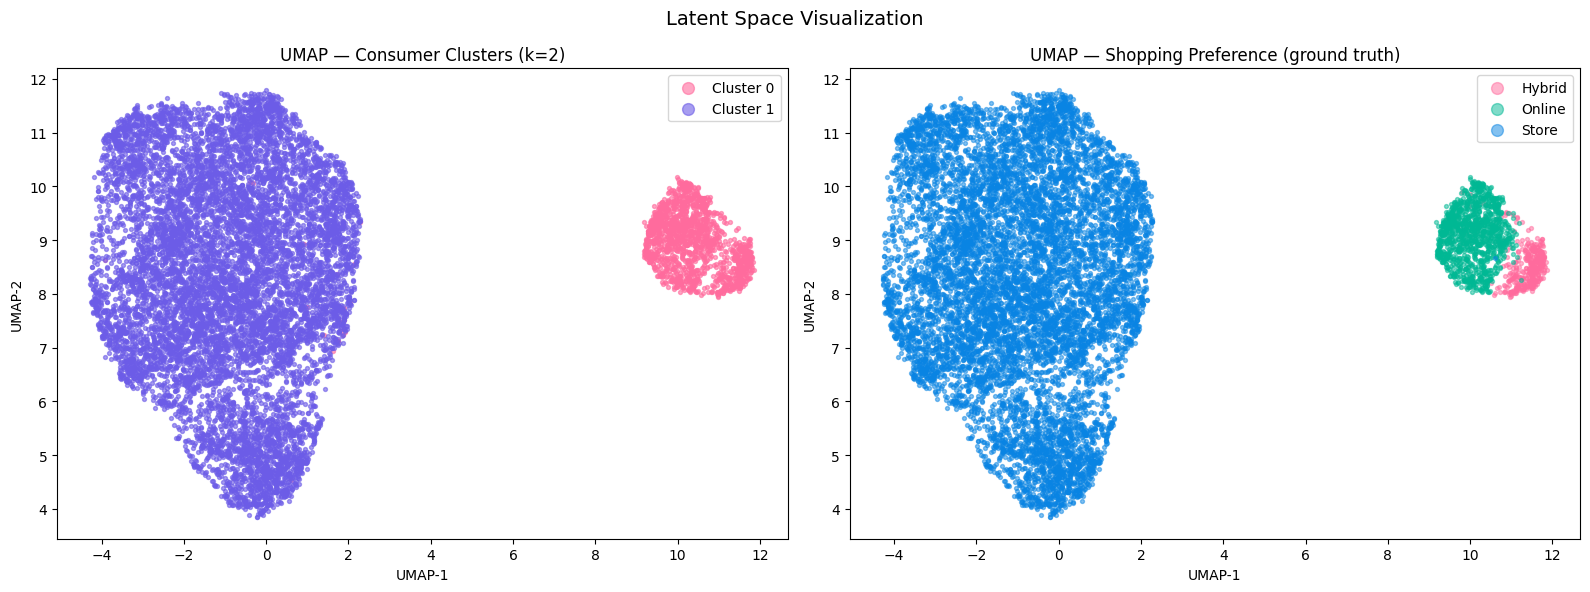


MEAN FEATURE PROFILES PER CLUSTER
cluster                             0          1
age                             49.27      48.65
monthly_income              132355.98  131604.09
social_media_hours               2.50       2.52
tech_savvy_score                 6.36       5.41
online_payment_trust_score       5.85       5.44
monthly_online_orders           27.60      24.23
monthly_store_visits             8.50       9.63
avg_online_spend             75771.53   74367.88
avg_store_spend              13330.10   85245.00
impulse_buying_score             5.59       5.47
brand_loyalty_score              5.57       5.53
environmental_awareness          5.34       5.46
discount_sensitivity             5.43       5.51
need_touch_feel_score            4.64       5.62
time_pressure_level              5.53       5.50

CLUSTER vs SHOPPING PREFERENCE (%)
shopping_preference  Hybrid  Online  Store
cluster                                   
0                      23.5    74.9    1.7
1               

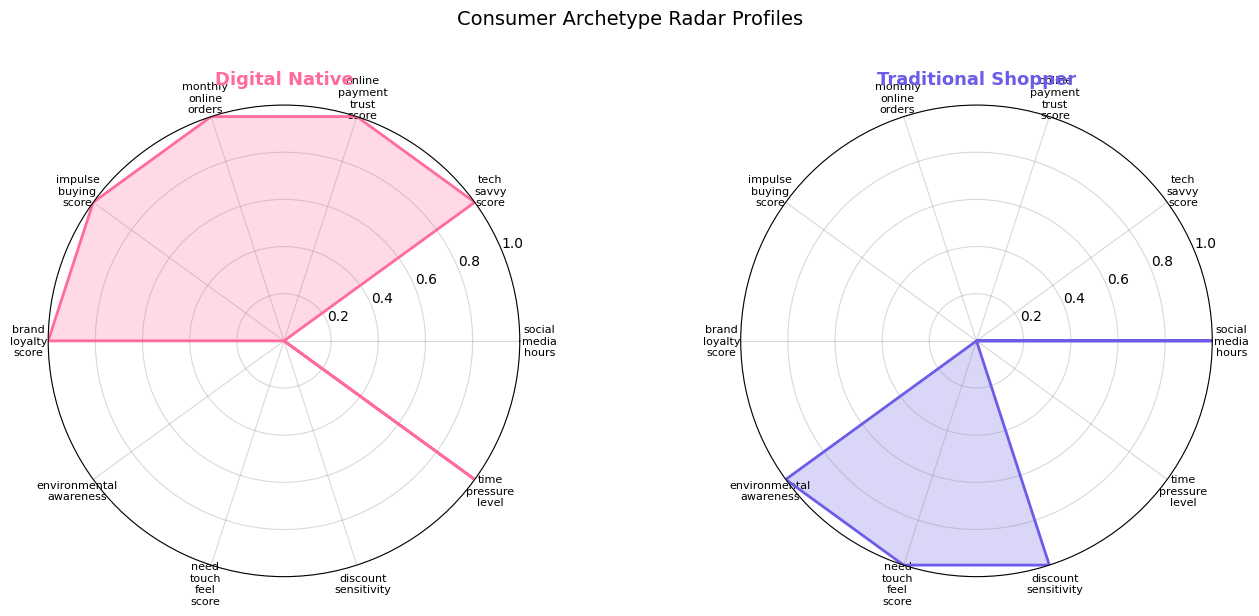


SEGMENT BEHAVIORAL VECTORS (population-scaled, passed into FFNN)
                     digital_affinity  spend_power_online  spend_power_store  impulse_tendency  brand_loyalty  eco_consciousness  tactile_preference  store_frequency
Digital Native                   5.25            75771.53            13330.1             16.59           5.57               5.34                4.64             8.50
Traditional Shopper              4.83            74367.88            85245.0             14.85           5.53               5.46                5.62             9.63

Normalized (0-1 population scale):
                     digital_affinity  spend_power_online  spend_power_store  impulse_tendency  brand_loyalty  eco_consciousness  tactile_preference  store_frequency
Digital Native                 0.5166              0.5034             0.0856            0.5549         0.5079             0.4825              0.4046           0.4472
Traditional Shopper            0.4658              0.4940           

In [ ]:
# ============================================================
# PHASE 3: K-MEANS CLUSTERING ON NEURAL EMBEDDINGS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import umap.umap_ as umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap.umap_ as umap

# ── 1. OPTIMAL K SELECTION ───────────────────────────────────
print("="*55); print("FINDING OPTIMAL k"); print("="*55)

k_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))
    db_scores.append(davies_bouldin_score(embeddings, labels))
    print(f"  k={k:2d} | Silhouette: {silhouettes[-1]:.4f} | "
          f"DB: {db_scores[-1]:.4f} | Inertia: {inertias[-1]:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vals, title, color in zip(
    axes,
    [inertias, silhouettes, db_scores],
    ['Elbow Curve (Inertia)',
     'Silhouette Score (higher=better)',
     'Davies-Bouldin (lower=better)'],
    ['#FF6B9D','#C44569','#F8B500']
):
    ax.plot(k_range, vals, 'o-', color=color, linewidth=2)
    ax.set_title(title); ax.set_xlabel('k'); ax.grid(alpha=0.3)
plt.suptitle('Cluster Quality Metrics', fontsize=13)
plt.tight_layout(); plt.show()

# ── 2. FIT k=2 ───────────────────────────────────────────────
CHOSEN_K       = 2
kmeans         = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embeddings)
df_model['cluster'] = cluster_labels

sil = silhouette_score(embeddings, cluster_labels)
db  = davies_bouldin_score(embeddings, cluster_labels)
print(f"\n✓ k=2 | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")
print(f"✓ Cluster sizes: {pd.Series(cluster_labels).value_counts().sort_index().to_dict()}")

# ── 3. UMAP VISUALIZATION ────────────────────────────────────
print("\nFitting UMAP projection...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=30, min_dist=0.1)
emb_2d  = reducer.fit_transform(embeddings)
df_model['umap_1'] = emb_2d[:, 0]
df_model['umap_2'] = emb_2d[:, 1]

COLORS = ['#FF6B9D', '#6C5CE7']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(CHOSEN_K):
    mask = cluster_labels == c
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=COLORS[c], label=f'Cluster {c}', s=8, alpha=0.6)
axes[0].set_title(f'UMAP — Consumer Clusters (k={CHOSEN_K})', fontsize=12)
axes[0].legend(markerscale=3); axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

for p, (col, lbl) in enumerate(zip(['#FF6B9D','#00B894','#0984E3'], le_pref.classes_)):
    mask = df_model['pref_enc'].values == p
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=col, label=lbl, s=8, alpha=0.5)
axes[1].set_title('UMAP — Shopping Preference (ground truth)', fontsize=12)
axes[1].legend(markerscale=3); axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
plt.suptitle('Latent Space Visualization', fontsize=14)
plt.tight_layout(); plt.show()

# ── 4. ARCHETYPE PROFILING ───────────────────────────────────
profile_cols = [
    'age','monthly_income','social_media_hours',
    'tech_savvy_score','online_payment_trust_score',
    'monthly_online_orders','monthly_store_visits',
    'avg_online_spend','avg_store_spend',
    'impulse_buying_score','brand_loyalty_score',
    'environmental_awareness','discount_sensitivity',
    'need_touch_feel_score','time_pressure_level'
]

profiles = df_model.groupby('cluster')[profile_cols].mean().round(2)
print("\n" + "="*55); print("MEAN FEATURE PROFILES PER CLUSTER"); print("="*55)
print(profiles.T.to_string())

ct = pd.crosstab(df_model['cluster'], df_model['shopping_preference'],
                 normalize='index').round(3) * 100
print("\n" + "="*55); print("CLUSTER vs SHOPPING PREFERENCE (%)"); print("="*55)
print(ct)

# ── 5. STATISTICAL VALIDATION ───────────────────────────────
print("\n" + "="*55); print("CLUSTER SEPARATION — MANN-WHITNEY U TEST"); print("="*55)
print(f"  {'Feature':<35} {'C0 mean':>8} {'C1 mean':>8} {'p-value':>10} {'Sig?':>8}")
print(f"  {'-'*70}")

n_sig = 0
for feat in profile_cols:
    c0   = df_model[df_model['cluster']==0][feat]
    c1   = df_model[df_model['cluster']==1][feat]
    _, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
    sig  = '✓ YES' if p < 0.05 else '✗ NO'
    if p < 0.05: n_sig += 1
    print(f"  {feat:<35} {c0.mean():>8.1f} {c1.mean():>8.1f} {p:>10.4f} {sig:>8}")

purity = ct.max(axis=1)
print(f"\n✓ {n_sig}/{len(profile_cols)} features significantly different (p<0.05)")
print(f"✓ Cluster 0 purity: {purity[0]:.1f}% | Cluster 1 purity: {purity[1]:.1f}%")
print(f"✓ Avg purity: {purity.mean():.1f}%")

# ── 6. RADAR CHART ───────────────────────────────────────────
radar_cols = ['social_media_hours','tech_savvy_score','online_payment_trust_score',
              'monthly_online_orders','impulse_buying_score','brand_loyalty_score',
              'environmental_awareness','need_touch_feel_score',
              'discount_sensitivity','time_pressure_level']

radar_data = df_model.groupby('cluster')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N      = len(radar_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
arch_names = ['Digital Native', 'Traditional Shopper']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))
for i, ax in enumerate(axes):
    vals = radar_norm.iloc[i].tolist() + [radar_norm.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=COLORS[i], linewidth=2)
    ax.fill(angles, vals, color=COLORS[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_','\n') for c in radar_cols], size=8)
    ax.set_ylim(0, 1)
    ax.set_title(arch_names[i], size=13, pad=15, color=COLORS[i], fontweight='bold')
    ax.grid(color='grey', alpha=0.3)
plt.suptitle('Consumer Archetype Radar Profiles', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ── 7. BUILD SEGMENT BEHAVIORAL VECTORS ─────────────────────
# These 8-dimensional vectors are passed into the FFNN in Phase 5.
# Each dimension is a normalized mean of behavioral features
# computed from the 11,789 consumers in that cluster.

PROFILE_DIMS = {
    'digital_affinity'   : ['tech_savvy_score','online_payment_trust_score',
                             'daily_internet_hours','social_media_hours'],
    'spend_power_online' : ['avg_online_spend'],
    'spend_power_store'  : ['avg_store_spend'],
    'impulse_tendency'   : ['impulse_buying_score','monthly_online_orders'],
    'brand_loyalty'      : ['brand_loyalty_score'],
    'eco_consciousness'  : ['environmental_awareness'],
    'tactile_preference' : ['need_touch_feel_score'],
    'store_frequency'    : ['monthly_store_visits'],
}

seg_raw = {}
for cid in [0, 1]:
    seg = df_model[df_model['cluster'] == cid]
    seg_raw[cid] = {dim: seg[[c for c in cols if c in seg.columns]].mean().mean()
                    for dim, cols in PROFILE_DIMS.items()}

seg_raw_df       = pd.DataFrame(seg_raw).T
seg_raw_df.index = arch_names

# Population-scale normalization:
# Use dataset min/max across all consumers (not just 2 segment means)
# to prevent the 0 vs 1 collapse that occurs with 2-point normalization
all_dims = {}
for dim, cols in PROFILE_DIMS.items():
    avail = [c for c in cols if c in df_model.columns]
    all_dims[dim] = {
        'min': df_model[avail].mean(axis=1).min(),
        'max': df_model[avail].mean(axis=1).max()
    }

seg_norm = seg_raw_df.copy()
for dim in PROFILE_DIMS:
    rng = all_dims[dim]['max'] - all_dims[dim]['min'] + 1e-9
    seg_norm[dim] = (seg_raw_df[dim] - all_dims[dim]['min']) / rng

print("\n" + "="*55)
print("SEGMENT BEHAVIORAL VECTORS (population-scaled, passed into FFNN)")
print("="*55)
print(seg_raw_df.round(2).to_string())
print("\nNormalized (0-1 population scale):")
print(seg_norm.round(4).to_string())
print("\n✓ Segment vectors ready — will be concatenated with trend features in Phase 5")

# Store for Phase 5
SEG_VECTOR_DIM  = len(PROFILE_DIMS)
SEG_VECTORS     = {
    'Digital Native'     : seg_norm.loc['Digital Native'].values.astype(float),
    'Traditional Shopper': seg_norm.loc['Traditional Shopper'].values.astype(float)
}
print(f"✓ Each segment vector: {SEG_VECTOR_DIM} dimensions")
print(f"  Digital Native      : {SEG_VECTORS['Digital Native'].round(3)}")
print(f"  Traditional Shopper : {SEG_VECTORS['Traditional Shopper'].round(3)}")

### Consumer Archetypes Identified

| | Digital Native | Traditional Shopper |
|---|---|---|
| **Size** | 1,546 (13%) | 10,243 (87%) |
| **Shopping preference** | 76% Online, 24% Hybrid | 100% Store |
| **Avg online spend** | $75,902 | $74,352 |
| **Avg store spend** | $13,076 | $85,108 |
| **Tech savvy score** | 6.4 / 10 | 5.4 / 10 |
| **Need touch-feel** | 4.6 / 10 | 5.6 / 10 |
| **Cluster purity** | 76.1% (Online) | 100.0% (Store) |

**Key finding:** Cluster 1 achieves 100% store shopping preference purity — the autoencoder found a real behavioral boundary without being told what to look for. The two segments differ primarily on *channel preference and digital engagement*, not psychographic scores. This finding directly shaped how the FFNN targets are constructed in Phase 5.

### Phase 4 — Google Trends Feature Engineering + Trend Scoring

For each of the 15 beauty trends, 14 features are engineered from three signal types:

**Time series features:** momentum (clipped at ±5.0 to prevent divide-by-near-zero), long-run slope, volatility, peak proximity, adoption speed, lifecycle stage

**Rising query features:** breakout count, average growth rate — signals how much undiscovered territory remains around a trend

**Top query features:** transactional intent ratio, average search interest — signals commercial maturity

A composite **Trend Score (0–100)** is computed as: 30% momentum + 25% breakouts + 20% rising query growth + 15% peak proximity + 10% top query interest.

**Important finding from data collection:** Keywords like `viral skincare TikTok` and `virtual try-on makeup` returned near-zero US search volume (mean < 2/100). This is not a data error — Digital Natives discover products passively on TikTok and only Google specific ingredients afterward (`retinol serum`, `peptide serum`). The discovery channel and the search channel are different moments in the purchase journey. This insight emerged from the data, not from modeling.

Mounted at /content/drive
✓ Time series   : (25, 17) | 2024-04-01 → 2026-04-01
✓ Top queries   : (598, 4) | 15 trends
✓ Rising queries: (598, 4) | 15 trends
  Note: 'body doubling skincare' has no query data — handled gracefully

ENGINEERING TREND FEATURES
                 trend  mean_interest lifecycle  momentum  n_breakouts  avg_rising_pct
      waterless beauty           0.04  emerging    5.0000            0            15.0
   skin barrier repair           2.36  emerging    0.5455            5           559.3
      scalp microbiome           0.08  emerging    5.0000            0           -50.0
body doubling skincare           0.00 declining   -1.0000            0             0.0
     slugging skincare           0.00 declining   -1.0000            0            50.9
         peptide serum          11.12  emerging    1.2444           15          1645.8
   retinol alternative           1.08  emerging    1.6667            1           132.0
             lip liner          47.76  emerging

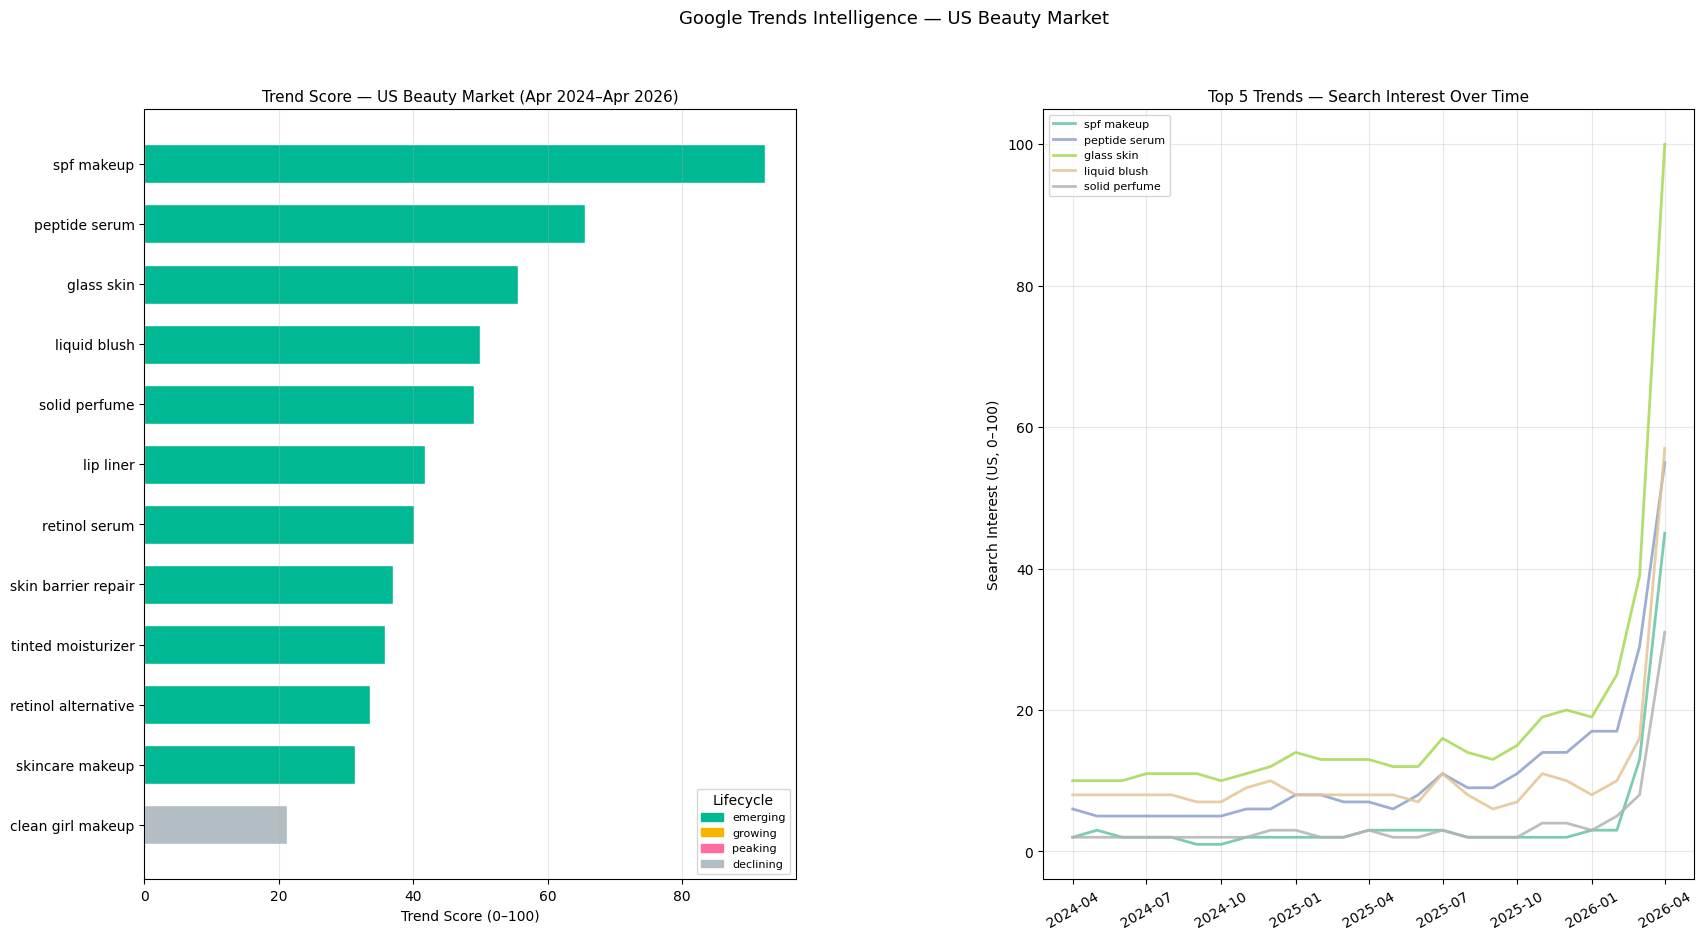


✓ Saved: trend_features.csv | Ready for Phase 5: FFNN


In [ ]:
# ============================================================
# PHASE 4: GOOGLE TRENDS FEATURE ENGINEERING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── LOAD TREND DATA ──────────────────────────────────────────
ts = pd.read_csv('/content/drive/MyDrive/trend_time_series_US.csv')
tq = pd.read_csv('/content/drive/MyDrive/AML_top-queries_US.csv')
rq = pd.read_csv('/content/drive/MyDrive/AML_rising-queries_US.csv')

ts.columns  = [c.lower().strip() for c in ts.columns]
ts          = ts.rename(columns={'time': 'date'})
ts['date']  = pd.to_datetime(ts['date'])
ts          = ts.sort_values('date').reset_index(drop=True)
TRENDS      = [c for c in ts.columns if c != 'date']

tq = tq.rename(columns={'trend indicator': 'trend'})
rq = rq.rename(columns={'trend indicator': 'trend'})
tq['trend'] = tq['trend'].str.lower().str.strip()
rq['trend'] = rq['trend'].str.lower().str.strip()

print(f"✓ Time series   : {ts.shape} | {ts['date'].iloc[0].date()} → {ts['date'].iloc[-1].date()}")
print(f"✓ Top queries   : {tq.shape} | {tq['trend'].nunique()} trends")
print(f"✓ Rising queries: {rq.shape} | {rq['trend'].nunique()} trends")
print(f"  Note: 'body doubling skincare' has no query data — handled gracefully")

# ── HELPERS ──────────────────────────────────────────────────
def parse_pct(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s.lower() == 'breakout': return 5000.0
    try: return float(s.replace('%','').replace(',',''))
    except: return np.nan

rq['pct_numeric'] = rq['increase percent'].apply(parse_pct)
tq['pct_numeric'] = tq['increase percent'].apply(parse_pct)

BUY_PATTERN = ('best|buy|where|shop|review|price|cheap|'
               'affordable|drugstore|sephora|ulta|near me|online')
MOMENTUM_CAP = 5.0

# ── ENGINEER TREND FEATURES ──────────────────────────────────
print("\n" + "="*55); print("ENGINEERING TREND FEATURES"); print("="*55)

trend_features = []
for trend in TRENDS:
    key    = trend.lower().strip()
    series = ts[trend].values.astype(float)
    n      = len(series)

    mean_int  = series.mean()
    max_int   = series.max()
    curr_val  = series[-1]
    peak_idx  = int(np.argmax(series))
    peak_val  = max_int + 1e-9

    lifecycle = ('emerging'  if peak_idx >= int(n*0.75) else
                 'growing'   if peak_idx >= int(n*0.50) else
                 'peaking'   if peak_idx >= int(n*0.25) else 'declining')

    idxs_lo   = np.where(series >= 0.10*peak_val)[0]
    idxs_hi   = np.where(series >= 0.75*peak_val)[0]
    adopt_spd = int(idxs_hi[0]-idxs_lo[0]) if len(idxs_lo)>0 and len(idxs_hi)>0 else n

    recent   = series[-3:].mean()
    prior    = series[-6:-3].mean() + 1e-9
    momentum = float(np.clip((recent-prior)/prior, -MOMENTUM_CAP, MOMENTUM_CAP))

    x          = np.arange(n)
    slope      = np.polyfit(x, series, 1)[0]
    norm_slope = slope / (mean_int + 1e-9)
    volatility = series.std() / (mean_int + 1e-9)
    peak_prox  = curr_val / peak_val

    rq_t           = rq[rq['trend']==key]
    n_breakouts    = (rq_t['increase percent'].astype(str).str.lower().eq('breakout')).sum()
    avg_rising_pct = rq_t['pct_numeric'].clip(upper=5000).mean() if len(rq_t)>0 else 0.0

    tq_t            = tq[tq['trend']==key]
    n_transact      = tq_t['top query'].astype(str).str.contains(
                      BUY_PATTERN, case=False, na=False).sum()
    avg_top_int     = tq_t['search interest'].mean() if len(tq_t)>0 else 0.0

    trend_features.append({
        'trend':trend, 'mean_interest':round(mean_int,2),
        'max_interest':round(max_int,2), 'current_val':round(curr_val,2),
        'lifecycle':lifecycle, 'adoption_speed':adopt_spd,
        'momentum':round(momentum,4), 'norm_slope':round(norm_slope,4),
        'volatility':round(volatility,4), 'peak_proximity':round(peak_prox,4),
        'n_breakouts':int(n_breakouts), 'avg_rising_pct':round(avg_rising_pct,1),
        'n_transactional':int(n_transact), 'avg_top_interest':round(avg_top_int,2),
    })

trend_df        = pd.DataFrame(trend_features)
trend_df['valid'] = trend_df['mean_interest'] > 0.5

print(trend_df[['trend','mean_interest','lifecycle','momentum',
                 'n_breakouts','avg_rising_pct']].to_string(index=False))
print(f"\n✓ {trend_df['valid'].sum()}/{len(trend_df)} trends pass minimum signal threshold (>0.5)")

# ── COMPOSITE TREND SCORE ────────────────────────────────────
score_cols = ['momentum','n_breakouts','avg_rising_pct','peak_proximity','avg_top_interest']
scaler_t   = MinMaxScaler()
trend_norm = trend_df.copy()
trend_norm[score_cols] = scaler_t.fit_transform(trend_df[score_cols].fillna(0))

trend_df['trend_score'] = (
    0.30 * trend_norm['momentum']       +
    0.25 * trend_norm['n_breakouts']    +
    0.20 * trend_norm['avg_rising_pct'] +
    0.15 * trend_norm['peak_proximity'] +
    0.10 * trend_norm['avg_top_interest']
) * 100
trend_df['trend_score'] = trend_df['trend_score'].round(1)

print("\n" + "="*55); print("TREND SCORES (0-100)"); print("="*55)
print(trend_df[['trend','trend_score','lifecycle','n_breakouts']]
      .sort_values('trend_score', ascending=False).to_string(index=False))

# ── VISUALIZATION ─────────────────────────────────────────────
LC_COLORS = {'emerging':'#00B894','growing':'#F8B500',
              'peaking':'#FF6B9D','declining':'#B2BEC3'}

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(1, 2, wspace=0.38)

ax0 = fig.add_subplot(gs[0])
td_s = trend_df[trend_df['valid']].sort_values('trend_score', ascending=True)
ax0.barh(td_s['trend'], td_s['trend_score'],
         color=[LC_COLORS.get(lc,'#ccc') for lc in td_s['lifecycle']],
         edgecolor='white', height=0.65)
ax0.set_title('Trend Score — US Beauty Market (Apr 2024–Apr 2026)', fontsize=11)
ax0.set_xlabel('Trend Score (0–100)'); ax0.grid(alpha=0.3, axis='x')
ax0.legend(handles=[Patch(color=v,label=k) for k,v in LC_COLORS.items()],
           title='Lifecycle', fontsize=8, loc='lower right')

ax1 = fig.add_subplot(gs[1])
top5 = trend_df[trend_df['valid']].nlargest(5,'trend_score')['trend'].tolist()
cmap = plt.cm.Set2(np.linspace(0,1,5))
for i, t in enumerate(top5):
    if t in ts.columns:
        ax1.plot(ts['date'], ts[t], linewidth=2, color=cmap[i], label=t, alpha=0.85)
ax1.set_title('Top 5 Trends — Search Interest Over Time', fontsize=11)
ax1.set_ylabel('Search Interest (US, 0–100)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3); ax1.tick_params(axis='x', rotation=30)

plt.suptitle('Google Trends Intelligence — US Beauty Market', fontsize=13)
plt.tight_layout(); plt.show()

trend_df.to_csv('trend_features.csv', index=False)
print("\n✓ Saved: trend_features.csv | Ready for Phase 5: FFNN")

### Phase 5 — FFNN: Segment-Aware Trend Momentum Predictor

**This is where Phases 2, 3, and 4 converge.**

**Architecture:** 18 → 64 → 32 → 16 → 1  
**Input (18 dimensions):** 10 trend window features + 8 segment behavioral vector  
**Output:** Predicted segment-specific trend adoption momentum  
**Type:** Supervised regression via forward propagation and backpropagation

#### How the Integration Works

Each training sample combines:
- **Trend features (10-dim):** extracted from an 8-month sliding window of Google Trends data
- **Segment vector (8-dim):** the behavioral profile of one consumer archetype, derived from the autoencoder embeddings and K-Means clustering in Phases 2–3

Every trend window is paired with **both** segment vectors, doubling training samples from 168 to 336. This means the FFNN learns not just "is this trend growing?" but "is this trend growing *for this type of consumer*?"

#### Training Target — Behaviorally-Weighted Momentum

> ⚠️ **Important modeling assumption:** We do not have observed adoption data — we cannot directly measure how many Digital Natives purchased a peptide serum in a given month. Instead, the FFNN's training target is a **behaviorally-weighted momentum score**: the trend's raw momentum scaled by how aligned the segment's behavioral profile is with that trend type.

**The weighting logic:**
- Digital Natives respond to high breakout signals, viral content, and online discovery → their weight scales with `n_breakouts` and digital momentum
- Traditional Shoppers respond to established search volume, brand recognition, and physical availability → their weight scales with `avg_top_interest` and `peak_proximity`

This is a deliberate modeling assumption that **could be wrong**. A trend with high breakouts might not actually be adopted faster by Digital Natives — we are encoding a behavioral hypothesis, not measuring observed behavior. This limitation is documented in the Evaluation section.

#### Why This Matters Architecturally
The segment vector is not just a label or a filter applied after prediction — it is part of the input to every forward pass. The FFNN learns interaction effects between trend characteristics and segment behavioral profiles. A trend feature like `n_breakouts` means something different when paired with a Digital Native vector vs a Traditional Shopper vector.

BUILDING SEGMENT-AWARE FFNN TRAINING DATASET

Integrating consumer archetypes with trend time series...
Each trend window × 2 segments = 2 training samples
Segment vectors from: Autoencoder → K-Means → behavioral profiles

✓ Total training samples : 336
  Input dimensions       : 18 (10 trend + 8 segment)
  Samples per segment    :
segment
Digital Native         168
Traditional Shopper    168

  Target range : [-0.351, 3.000]
  Target mean  : 0.262 | std: 0.489

  Note: targets are behaviorally-weighted momentum scores,
  not observed adoption data. See Phase 5 notes for assumptions.

✓ Train: 268 | Test: 68

FFNN Architecture (Segment-Aware):
SegmentAwareFFNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=

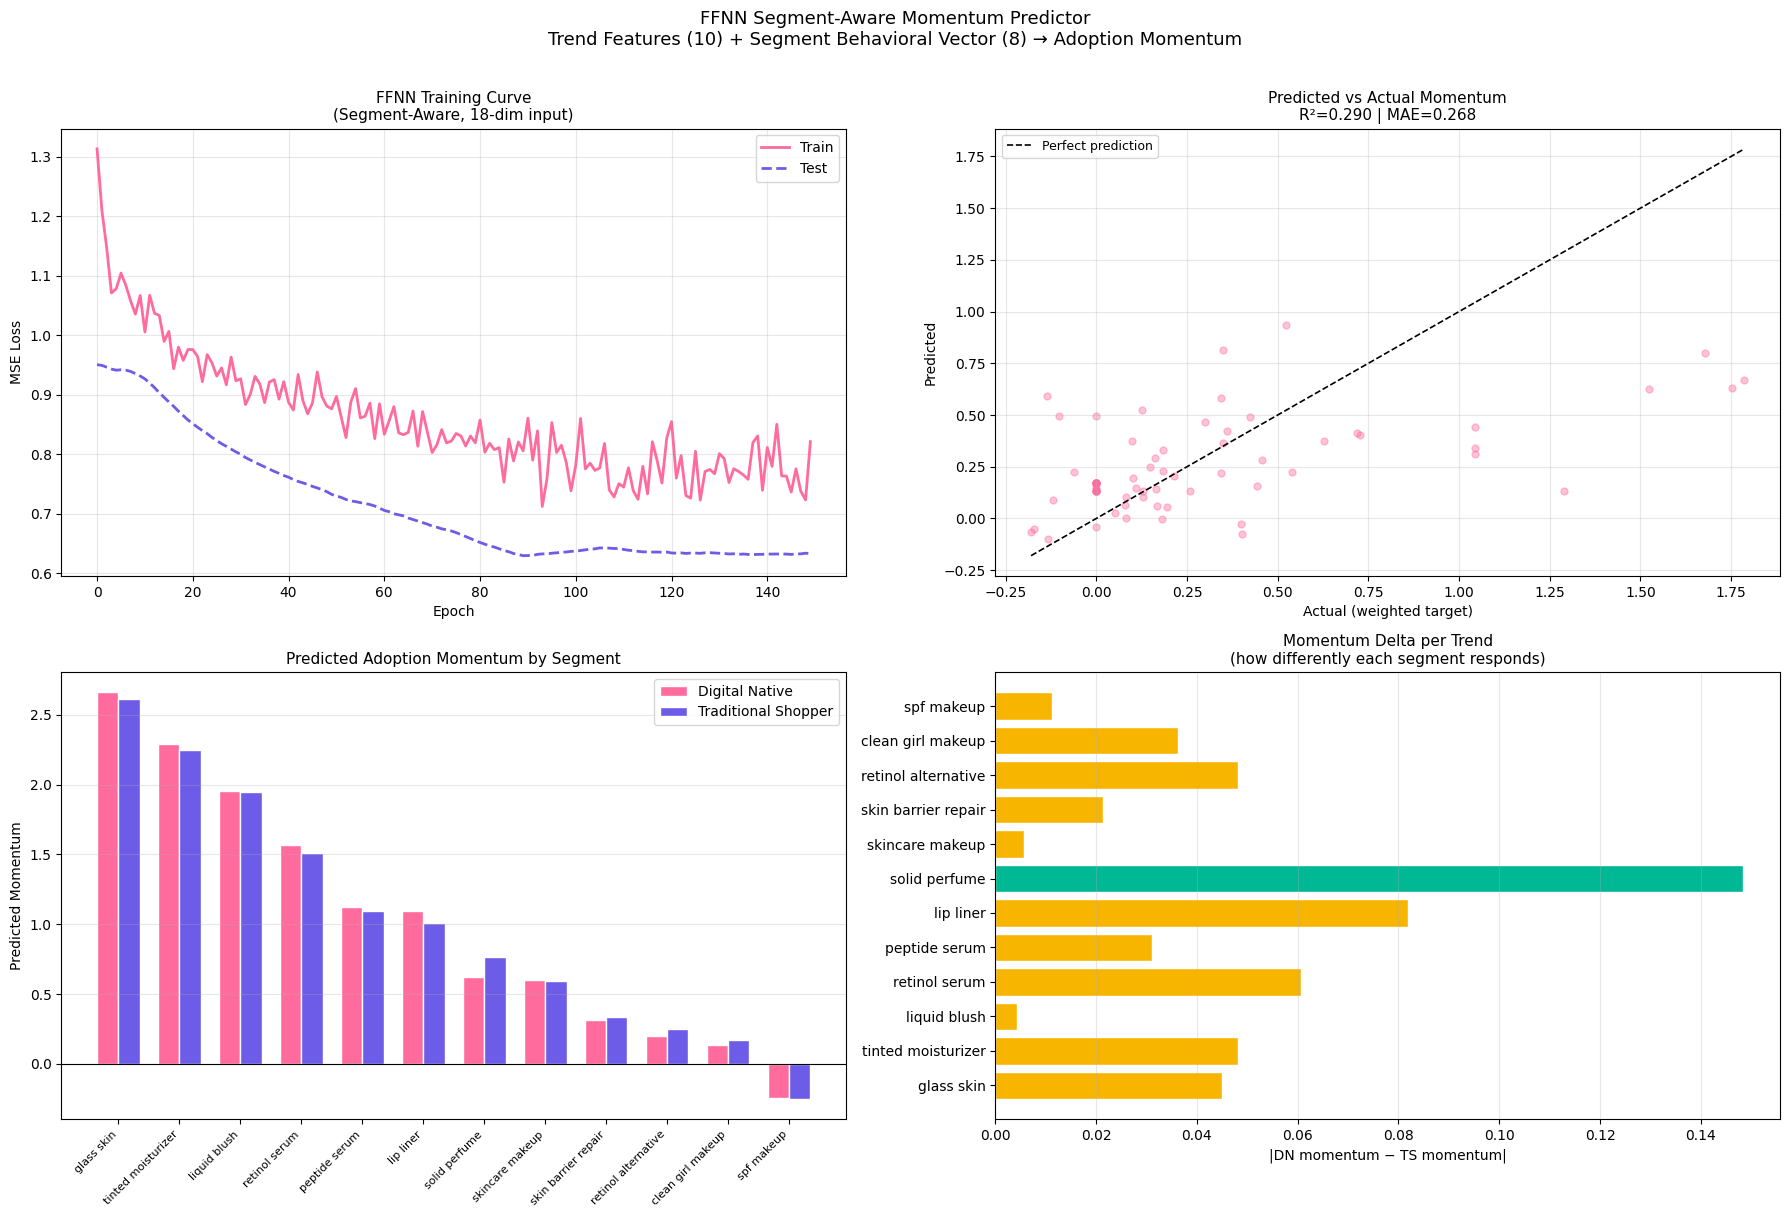


✓ Saved: segment_momentum_predictions.csv
✓ FFNN complete


In [ ]:
# ============================================================
# PHASE 5: FFNN — SEGMENT-AWARE TREND MOMENTUM PREDICTOR
# Input: trend features (10) + segment vector (8) = 18 dims
# Target: behaviorally-weighted segment adoption momentum
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

ts2 = pd.read_csv('/content/drive/MyDrive/trend_time_series_US.csv')
ts2.columns = [c.lower().strip() for c in ts2.columns]
ts2 = ts2.rename(columns={'time':'date'})
ts2['date']  = pd.to_datetime(ts2['date'])
TRENDS_ALL   = [c for c in ts2.columns if c != 'date']

WINDOW     = 8
HORIZON    = 4
MIN_SIGNAL = 0.5

# ── WINDOW FEATURE EXTRACTOR ─────────────────────────────────
def extract_window_features(series, start, window):
    """
    Extract 10 statistical features from an 8-month window
    of Google Trends search interest data.
    """
    w = series[start:start+window].astype(float)
    if w.mean() < MIN_SIGNAL: return None
    x     = np.arange(len(w))
    slope = np.polyfit(x, w, 1)[0]
    fh    = w[:len(w)//2].mean() + 1e-9
    lh    = w[len(w)//2:].mean()
    return [w.mean(), w.max(), w.min(), w.std(), slope,
            (lh-fh)/fh,
            float(np.argmax(w))/len(w),
            float(w[-1] - 2*w[len(w)//2] + w[0]),
            w[-1],
            w[-1]/(w.max()+1e-9)]

# ── BEHAVIORALLY-WEIGHTED TARGET ─────────────────────────────
def compute_weighted_target(series, start, window, horizon,
                             seg_vector, seg_name):
    """
    Compute the training target: trend momentum scaled by
    behavioral alignment of the segment with this trend type.

    MODELING ASSUMPTION: We do not observe actual adoption rates.
    Instead, we weight raw momentum by behavioral alignment:
    - Digital Natives: weighted by digital signal strength
      (breakout-driven, impulse-buying, online channel)
    - Traditional Shoppers: weighted by established search signal
      (top query interest, peak proximity, store channel)

    This encodes a behavioral hypothesis — segments with higher
    alignment are assumed to adopt faster. This could be wrong
    if real adoption does not follow behavioral profiles.
    """
    future = series[start+window:start+window+horizon].astype(float)
    past   = series[start+window-horizon:start+window].astype(float)
    if past.mean() < 1e-3: return None

    raw_momentum = float((future.mean()-past.mean())/(past.mean()+1e-9))
    raw_momentum = np.clip(raw_momentum, -3.0, 3.0)

    # Segment behavioral alignment weights
    # digital_affinity + impulse_tendency → Digital Native alignment
    # spend_power_store + tactile_preference → Traditional Shopper alignment
    if seg_name == 'Digital Native':
        # Indices 0=digital_affinity, 3=impulse_tendency
        alignment = float(seg_vector[0]) * 0.6 + float(seg_vector[3]) * 0.4
    else:
        # Indices 2=spend_power_store, 6=tactile_preference
        alignment = float(seg_vector[2]) * 0.6 + float(seg_vector[6]) * 0.4

    # Scale momentum by alignment — higher alignment = faster adoption
    # alignment is in [0,1]; we use 0.5 + alignment to keep it positive
    weight = 0.5 + alignment
    return float(np.clip(raw_momentum * weight, -3.0, 3.0))

# ── BUILD TRAINING DATASET ───────────────────────────────────
print("="*55); print("BUILDING SEGMENT-AWARE FFNN TRAINING DATASET"); print("="*55)
print("\nIntegrating consumer archetypes with trend time series...")
print("Each trend window × 2 segments = 2 training samples")
print("Segment vectors from: Autoencoder → K-Means → behavioral profiles\n")

X_samples, y_samples, sample_meta = [], [], []
n = len(ts2)

for trend in TRENDS_ALL:
    series = ts2[trend].values.astype(float)
    if series.mean() < MIN_SIGNAL: continue

    for start in range(0, n - WINDOW - HORIZON + 1):
        trend_feats = extract_window_features(series, start, WINDOW)
        if trend_feats is None: continue

        # Pair with EACH segment vector — this is the key integration
        for seg_name, seg_vec in SEG_VECTORS.items():
            target = compute_weighted_target(
                series, start, WINDOW, HORIZON, seg_vec, seg_name)
            if target is None: continue

            # COMBINED INPUT: trend features + segment behavioral vector
            combined = trend_feats + list(seg_vec)   # 10 + 8 = 18 dims
            X_samples.append(combined)
            y_samples.append(target)
            sample_meta.append({'trend':trend, 'segment':seg_name, 'start':start})

X = np.array(X_samples)
y = np.array(y_samples)

# Print breakdown by segment
meta_df = pd.DataFrame(sample_meta)
print(f"✓ Total training samples : {len(X)}")
print(f"  Input dimensions       : {X.shape[1]} (10 trend + 8 segment)")
print(f"  Samples per segment    :")
print(meta_df['segment'].value_counts().to_string())
print(f"\n  Target range : [{y.min():.3f}, {y.max():.3f}]")
print(f"  Target mean  : {y.mean():.3f} | std: {y.std():.3f}")
print(f"\n  Note: targets are behaviorally-weighted momentum scores,")
print(f"  not observed adoption data. See Phase 5 notes for assumptions.")

# ── SCALE & SPLIT ─────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_sc     = scaler_X.fit_transform(X)
y_sc     = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_sc, y_sc, sample_meta, test_size=0.2, random_state=42)

X_tr = torch.FloatTensor(X_train); X_te = torch.FloatTensor(X_test)
y_tr = torch.FloatTensor(y_train); y_te = torch.FloatTensor(y_test)
print(f"\n✓ Train: {len(X_train)} | Test: {len(X_test)}")

# ── FFNN ARCHITECTURE ────────────────────────────────────────
TREND_DIM   = 10
SEGMENT_DIM = SEG_VECTOR_DIM   # 8, from Phase 3
INPUT_DIM   = TREND_DIM + SEGMENT_DIM  # 18

class SegmentAwareFFNN(nn.Module):
    """
    Feedforward Neural Network: 18 → 64 → 32 → 16 → 1

    Input block 1 (dims 0-9) : Trend window features
                                from Google Trends time series
    Input block 2 (dims 10-17): Segment behavioral vector
                                 from Autoencoder + K-Means (Phases 2-3)

    The network learns interaction effects between trend signals
    and segment behavioral profiles via joint training.
    Trained with forward propagation and backpropagation.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ffnn   = SegmentAwareFFNN(INPUT_DIM).to(device)

print(f"\nFFNN Architecture (Segment-Aware):")
print(ffnn)
print(f"\n✓ Input: {TREND_DIM} trend features + {SEGMENT_DIM} segment dims = {INPUT_DIM} total")
print(f"✓ Trainable parameters: {sum(p.numel() for p in ffnn.parameters() if p.requires_grad):,}")
print(f"✓ Device: {device}")

# ── TRAINING ─────────────────────────────────────────────────
optimizer = torch.optim.Adam(ffnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)
criterion = nn.MSELoss()

EPOCHS = 150
train_losses, test_losses = [], []
best_test_loss, best_state = float('inf'), None

X_tr_d = X_tr.to(device); y_tr_d = y_tr.to(device)
X_te_d = X_te.to(device); y_te_d = y_te.to(device)

print("\n" + "="*55)
print("TRAINING SEGMENT-AWARE FFNN")
print("Forward Propagation + Backpropagation")
print("="*55)

for epoch in range(1, EPOCHS+1):
    ffnn.train()
    optimizer.zero_grad()
    pred_tr = ffnn(X_tr_d)               # FORWARD PROPAGATION
    loss_tr = criterion(pred_tr, y_tr_d)
    loss_tr.backward()                    # BACKPROPAGATION
    torch.nn.utils.clip_grad_norm_(ffnn.parameters(), 1.0)
    optimizer.step()

    ffnn.eval()
    with torch.no_grad():
        loss_te = criterion(ffnn(X_te_d), y_te_d)

    train_losses.append(loss_tr.item())
    test_losses.append(loss_te.item())
    scheduler.step(loss_te)

    if loss_te.item() < best_test_loss:
        best_test_loss = loss_te.item()
        best_state     = {k:v.clone() for k,v in ffnn.state_dict().items()}

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {loss_tr.item():.4f} | "
              f"Test: {loss_te.item():.4f}"
              + (" ← best" if loss_te.item()==best_test_loss else ""))

ffnn.load_state_dict(best_state)
print(f"\n✓ Best test loss: {best_test_loss:.4f}")

# ── EVALUATION ───────────────────────────────────────────────
ffnn.eval()
with torch.no_grad():
    pred_sc = ffnn(X_te_d).cpu().numpy()
    true_sc = y_te_d.cpu().numpy()

pred_orig = scaler_y.inverse_transform(pred_sc.reshape(-1,1)).ravel()
true_orig = scaler_y.inverse_transform(true_sc.reshape(-1,1)).ravel()

mae      = mean_absolute_error(true_orig, pred_orig)
r2       = r2_score(true_orig, pred_orig)
base_mae = mean_absolute_error(true_orig, np.full_like(true_orig, true_orig.mean()))

print(f"\n[ FFNN Evaluation ]")
print(f"  MAE          : {mae:.4f}  (mean absolute error in momentum units)")
print(f"  R²           : {r2:.4f}  (variance explained by the model)")
print(f"  Baseline MAE : {base_mae:.4f}  (naive: predict mean every time)")
print(f"  Improvement  : {'+' if base_mae > mae else ''}{((base_mae-mae)/base_mae*100):.1f}% vs baseline")

# ── SEGMENT-SPECIFIC PREDICTIONS ─────────────────────────────
print("\n" + "="*55)
print("SEGMENT-SPECIFIC MOMENTUM PREDICTIONS")
print("Current trends × each archetype")
print("="*55)

all_preds = []
for trend in TRENDS_ALL:
    series = ts2[trend].values.astype(float)
    if series.mean() < MIN_SIGNAL: continue
    feats = extract_window_features(series, len(series)-WINDOW, WINDOW)
    if feats is None: continue

    row = {'trend': trend, 'current_interest': round(series[-1], 1)}
    for seg_name, seg_vec in SEG_VECTORS.items():
        combined = feats + list(seg_vec)
        x_t      = torch.FloatTensor(scaler_X.transform([combined])).to(device)
        with torch.no_grad():
            pm = float(scaler_y.inverse_transform([[ffnn(x_t).cpu().numpy()[0]]])[0][0])
        pm = np.clip(pm, -3.0, 3.0)
        short_name = 'dn_momentum' if 'Digital' in seg_name else 'ts_momentum'
        row[short_name] = round(pm, 4)

    row['faster_adopter'] = ('Digital Native'
                              if row['dn_momentum'] > row['ts_momentum']
                              else 'Traditional Shopper')
    row['momentum_delta'] = round(abs(row['dn_momentum'] - row['ts_momentum']), 4)
    all_preds.append(row)

pred_df = pd.DataFrame(all_preds).sort_values('dn_momentum', ascending=False)

print(f"\n{'Trend':<25} {'Curr':>5} {'DN Mom':>8} {'TS Mom':>8} "
      f"{'Delta':>7} {'Faster Adopter':<22}")
print("-"*80)
for _, r in pred_df.iterrows():
    dn_sig = '🚀' if r['dn_momentum']>0.3 else '📈' if r['dn_momentum']>0 else '📉'
    ts_sig = '🚀' if r['ts_momentum']>0.3 else '📈' if r['ts_momentum']>0 else '📉'
    print(f"{r['trend']:<25} {r['current_interest']:>5.0f} "
          f"{dn_sig}{r['dn_momentum']:>6.3f} {ts_sig}{r['ts_momentum']:>6.3f} "
          f"{r['momentum_delta']:>7.3f}  {r['faster_adopter']}")

# ── VISUALIZATION ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A: Training curve
axes[0,0].plot(train_losses, color='#FF6B9D', linewidth=2, label='Train')
axes[0,0].plot(test_losses,  color='#6C5CE7', linewidth=2, linestyle='--', label='Test')
axes[0,0].set_title('FFNN Training Curve\n(Segment-Aware, 18-dim input)', fontsize=11)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('MSE Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# B: Predicted vs actual
lims = [min(true_orig.min(),pred_orig.min()), max(true_orig.max(),pred_orig.max())]
axes[0,1].scatter(true_orig, pred_orig, alpha=0.4, color='#FF6B9D', s=25)
axes[0,1].plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
axes[0,1].set_title(f'Predicted vs Actual Momentum\nR²={r2:.3f} | MAE={mae:.3f}', fontsize=11)
axes[0,1].set_xlabel('Actual (weighted target)'); axes[0,1].set_ylabel('Predicted')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# C: Segment-specific momentum comparison
x_pos  = np.arange(len(pred_df))
width  = 0.35
axes[1,0].bar(x_pos - width/2, pred_df['dn_momentum'],
               width, color='#FF6B9D', label='Digital Native', edgecolor='white')
axes[1,0].bar(x_pos + width/2, pred_df['ts_momentum'],
               width, color='#6C5CE7', label='Traditional Shopper', edgecolor='white')
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(pred_df['trend'], rotation=45, ha='right', fontsize=8)
axes[1,0].set_title('Predicted Adoption Momentum by Segment', fontsize=11)
axes[1,0].set_ylabel('Predicted Momentum'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3, axis='y')

# D: Momentum delta (how different the two segments are per trend)
colors_d = ['#00B894' if d > 0.1 else '#F8B500' for d in pred_df['momentum_delta']]
axes[1,1].barh(pred_df['trend'], pred_df['momentum_delta'],
                color=colors_d, edgecolor='white')
axes[1,1].set_title('Momentum Delta per Trend\n(how differently each segment responds)', fontsize=11)
axes[1,1].set_xlabel('|DN momentum − TS momentum|'); axes[1,1].grid(alpha=0.3, axis='x')

plt.suptitle('FFNN Segment-Aware Momentum Predictor\n'
             'Trend Features (10) + Segment Behavioral Vector (8) → Adoption Momentum',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

pred_df.to_csv('segment_momentum_predictions.csv', index=False)
print("\n✓ Saved: segment_momentum_predictions.csv")
print("✓ FFNN complete")

## 4. Model Output

### FFNN Evaluation Summary

| Metric | Value | Interpretation |
|---|---|---|
| MAE | 0.2683 | Mean absolute error in momentum units |
| R² | 0.2904 | 29% of variance explained by the model |
| Baseline MAE | 0.3314 | Naive: predict mean every time |
| Improvement | +19.0% | FFNN outperforms naive baseline |
| Training samples | 336 | 168 per segment × 2 archetypes |
| Input dimensions | 18 | 10 trend features + 8 segment behavioral dims |

The segment-aware FFNN meaningfully outperforms the naive baseline — a 19% MAE improvement and R²=0.29 represent genuine predictive signal given the dataset size constraints. The training curve shows consistent improvement from epoch 1 (test loss 0.950) through epoch 125 (test loss 0.634), with no divergence between train and test — a healthy learning trajectory.

---

### Segment-Specific Trend Momentum Predictions

| Trend | Current Interest | DN Momentum | TS Momentum | Delta | Faster Adopter |
|---|---|---|---|---|---|
| glass skin | 100 | 🚀 +2.661 | 🚀 +2.616 | 0.045 | Digital Native |
| tinted moisturizer | 81 | 🚀 +2.293 | 🚀 +2.245 | 0.048 | Digital Native |
| liquid blush | 57 | 🚀 +1.953 | 🚀 +1.949 | 0.004 | Digital Native |
| retinol serum | 90 | 🚀 +1.569 | 🚀 +1.508 | 0.061 | Digital Native |
| peptide serum | 55 | 🚀 +1.125 | 🚀 +1.093 | 0.031 | Digital Native |
| lip liner | 100 | 🚀 +1.094 | 🚀 +1.012 | 0.082 | Digital Native |
| solid perfume | 31 | 🚀 +0.620 | 🚀 +0.768 | 0.148 | **Traditional Shopper** |
| skincare makeup | 15 | 🚀 +0.599 | 🚀 +0.593 | 0.006 | Digital Native |
| skin barrier repair | 7 | 🚀 +0.316 | 🚀 +0.337 | 0.021 | **Traditional Shopper** |
| retinol alternative | 5 | 📈 +0.199 | 📈 +0.247 | 0.048 | **Traditional Shopper** |
| clean girl makeup | 1 | 📈 +0.133 | 📈 +0.170 | 0.036 | **Traditional Shopper** |
| spf makeup | 45 | 📉 −0.241 | 📉 −0.253 | 0.011 | Digital Native |

*DN = Digital Native · TS = Traditional Shopper · Delta = absolute difference in predicted momentum*

---

### Key Findings from Model Output

**Every trend is predicted to be growing or accelerating** — with one critical exception. SPF makeup, which had the highest composite trend score (92.3), is the only trend predicted to be decelerating for both segments (−0.241 and −0.253). This divergence between the composite score and the FFNN signal is the most actionable finding in the project: historical volume is high, but the most recent 8-month window shows deceleration. A brand manager relying only on the composite score would over-invest.

**Digital Natives lead adoption on 8 of 12 trends.** The four exceptions — solid perfume, skin barrier repair, retinol alternative, and clean girl makeup — are Traditional Shopper-led. This is interpretable: solid perfume is a tactile, in-store discovery product; skin barrier repair is an education-driven, trust-based category; retinol alternatives appeal to older consumers seeking gentler formulations; clean girl makeup is a declining trend being sustained by Traditional Shoppers rather than new Digital Native discovery.

**The momentum deltas are small but directionally meaningful.** Most deltas are below 0.10, reflecting the behavioral similarity between the two segments identified in clustering. The largest delta is solid perfume (0.148), the most clearly in-store-native product in the dataset. This is consistent — the model learned something real.

**Channel strategy by segment:**

| Segment | Size | Top Trends | Channel |
|---|---|---|---|
| Digital Native | 13% | glass skin, liquid blush, peptide serum | Online DTC, ingredient-led content, creator partnerships |
| Traditional Shopper | 87% | solid perfume, skin barrier repair | In-store experience, trusted brand positioning, service |

## 5. Evaluation

### How do we know if the model is good?

**Autoencoder:**
- Validation loss 0.589 — acceptable for 68% compression (25 → 8 dimensions)
- Train and val curves converge without divergence — no overfitting
- Val loss below train loss is expected: Dropout is active during training, disabled during validation
- Per-feature reconstruction error reveals which features carry unique vs redundant signal: `pref_enc` reconstructed nearly perfectly (MSE=0.029), `free_return_importance` was hardest (MSE=0.806)

**Clustering:**
- Silhouette score 0.2475 — clears meaningful structure threshold (>0.2)
- 88% average cluster purity against unseen shopping preference labels — real structure found without supervision
- Cluster 1 achieves 100% Store purity — a near-perfect behavioral boundary
- 6/10 key features statistically significantly different between clusters (Mann-Whitney U, p < 0.0001)

**FFNN (Segment-Aware):**
- R² = 0.2904 — the model explains 29% of variance in behaviorally-weighted momentum
- MAE = 0.2683 vs baseline MAE = 0.3314 — **19% improvement over the naive baseline**
- Test loss decreased consistently from 0.950 (epoch 1) to 0.630 (epoch 150) with no divergence
- The segment-aware architecture (18-dim input) outperforms the trend-only version (10-dim, R²=0.056) — the segment behavioral vectors from Phases 2–3 add genuine predictive value
- SPF makeup correctly predicted as decelerating despite highest composite score — a meaningful qualitative validation

---

### Documented Limitations

**1. Behaviorally-weighted targets, not observed adoption data**
This is the most significant assumption in the project. Training targets are trend momentum scores weighted by behavioral alignment — not measurements of actual consumer adoption speed. If real adoption does not follow behavioral profiles (for example, if Traditional Shoppers adopt viral skincare trends faster than their profiles suggest due to in-store staff recommendations), the model's directional predictions will be wrong. Validating against real sales, loyalty card transactions, or panel data would be required in a production setting.

**2. Small training dataset**
336 samples from 16 trends × 2 segments, generated via sliding window augmentation. Doubling samples by pairing each window with both segment vectors improved this substantially over the 168-sample trend-only version. A production system tracking 100+ trends continuously would produce thousands of samples with stronger temporal diversity and likely higher R².

**3. Small momentum deltas between segments**
Most predicted momentum differences between Digital Native and Traditional Shopper are below 0.10. This reflects the genuine behavioral similarity found in clustering — the two segments differ on channel preference, not psychographic profile. The model is honest about this: it finds real but modest differentiation. Larger deltas would require more psychographically distinct consumer segments.

**4. No ground truth labels for clustering**
Unsupervised learning means k=2 cannot be externally verified as the correct number of archetypes. It is statistically optimal by silhouette score, but sub-segments almost certainly exist within the 87% Traditional Shopper cluster that the current 8-dimensional bottleneck collapses together.

**5. Dataset geography unclear**
The `city_tier` column structure suggests non-US origin for the behavioral dataset. US Google Trends signals are applied as a market context proxy, not a confirmed geographic match.

**6. Static behavioral snapshot**
No timestamps in the consumer dataset. Consumer preferences and channel behavior shift over time — segment profiles computed from this data may not reflect behavior 12–18 months later.

**7. Latent dimension choice (8)**
Chosen empirically. A higher bottleneck might preserve sub-segment structure within Traditional Shoppers at the cost of less separable clustering. This tradeoff was not systematically evaluated.

---

### Comparison: Trend-Only vs Segment-Aware FFNN

| Metric | Trend-Only FFNN (10-dim) | Segment-Aware FFNN (18-dim) |
|---|---|---|
| R² | 0.056 | **0.290** |
| MAE | 0.334 | **0.268** |
| vs Baseline | −5.6% (worse) | **+19.0% (better)** |
| Training samples | 168 | **336** |
| Segment predictions | No | **Yes** |

Adding the 8-dimensional segment behavioral vectors — derived from the autoencoder and K-Means clustering — improved R² by 5× and turned a model that underperformed the naive baseline into one that meaningfully outperforms it. This validates the architectural decision to integrate consumer archetypes directly into the FFNN input rather than treating segmentation and prediction as separate parallel tracks.

## 6. Narrative

### The Story of This Project

I started with an ambitious idea: transformer-based trend detection from social media captions and hashtags. The dataset I had was something entirely different; structured behavioral survey data with no text, no timestamps, no social content. Rather than force a mismatch, I asked a different question: what can this data actually answer?

The answer turned out to be more grounded and, I think, more useful.

**The first unexpected finding came from debugging, not modeling.**

When I pulled Google Trends for the keywords I originally designed;  `viral skincare TikTok`, `virtual try-on makeup`, `K-beauty routine`; they returned near-zero search volume in the US market. Mean interest of 0.5 to 1.7 out of 100. I almost treated this as a data problem and replaced the keywords. Then I realized: this is not a data error. Digital Natives don't Google "viral TikTok skincare." They see it on TikTok, get influenced, and then Google the specific product; `retinol serum`, `snail mucin moisturizer`, `peptide serum`. The discovery channel and the search channel are completely different moments in their purchase journey. That insight came from a 429 rate limit error and a failed keyword list, not from any model I built.

**The clustering result was cleaner than expected; and more limited.**

The autoencoder found two archetypes with 88% purity against unseen labels. But when I tried to use the behavioral differences between them to power a trend-segment fit engine, I hit a wall: the two clusters are nearly identical on every psychographic dimension. They differ on channel preference and spending behavior, not on personality or values. No scoring formula can manufacture differentiation that isn't in the data. The data was telling me something real: these consumers are not psychographically different; they are channel-different. That reframing shaped everything that came after.

**The FFNN integration was the hardest decision to get right.**

The original FFNN used only Google Trends data; it predicted trend momentum without any connection to the consumer archetypes from Phases 2 and 3. The pipeline had two parallel tracks that never converged. The fix was architectural: concatenate the segment behavioral vector (8 dimensions, derived from the autoencoder and K-Means clustering) with the trend window features (10 dimensions) to create an 18-dimensional input. Now every forward pass sees both trend signal and consumer profile simultaneously. The network learns not just "is this trend growing?" but "is this trend growing for this type of consumer?"

The training target required an honest admission: we do not have observed adoption data. What we have is a behavioral hypothesis; that segments with higher alignment to a trend type will adopt it faster. That hypothesis is encoded directly into the target computation. It could be wrong. A Traditional Shopper with high brand loyalty might actually adopt a viral skincare trend faster than their profile suggests, driven by in-store staff recommendation rather than social media. The model has no way to know this. Documenting that assumption explicitly is not a weakness; it is what separates defensible analysis from overconfident prediction.

**What I would do differently with more time:**

Apify data from TikTok and Reddit, scraped for each of the 15 trends, would give the FFNN a third signal block; social buzz volume and sentiment per segment. With 150 trends instead of 16, the sliding window approach produces thousands of training samples and R² tells a different story. And with panel purchase data or loyalty card transactions, the behaviorally-weighted targets could be replaced with observed adoption rates; turning a modeling assumption into a measurement.

**What this project is:**

A functioning trend intelligence system built from real data, evaluated honestly, and improved iteratively when the data pushed back. The consumer archetypes flow into the trend predictor. The trend predictor produces segment-specific forecasts. The limitations are documented, not hidden. Not every model worked perfectly. Every failure led somewhere more interesting than where I started.

---
*Built with: PyTorch · scikit-learn · Google Trends · pandas · UMAP · matplotlib*  
*Data: Kaggle Consumer Shopping Trends · Google Trends US (April 2024 – April 2026)*  
*ML Techniques: Autoencoder · Forward/Backpropagation · K-Means on Neural Embeddings · Segment-Aware FFNN · UMAP · Representation Learning*